<a href="https://colab.research.google.com/github/vladmsnk/dl_aith/blob/hw1/dl_hw_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm
from collections import defaultdict

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [149]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [150]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Данные

In [151]:
df = pd.read_csv('/content/cybersequrity.csv', sep=',')

In [152]:
df.head(10)

,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0
5,26,8,0.0,0,0,3,1,1,1,5,0.022222,0.022222,7,0.022222,0.066667,1
6,26,8,0.0,0,0,7,5,5,7,11,0.111657,0.111657,13,0.138874,0.149805,0
7,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.045455,1
8,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,5,0.000000,0.048780,0
9,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.047619,0


In [153]:
df.shape

(10000, 16)

In [154]:
X, y = df.drop(['Class'], axis=1), df['Class']

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [156]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


In [157]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

In [158]:
X_val_scaled  = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [159]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, "values") else y,
                              dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [160]:
train_dataset = CustomDataset(X_train_scaled, y_train)
val_dataset = CustomDataset(X_val_scaled, y_val)
test_dataset = CustomDataset(X_test_scaled, y_test)

Создадим объекты DataLoader с batch_size = 32 (начнем с этого размера батча)

In [161]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Создадим простейшную модель с 3-мя линейными слоями и функцией активации Relu (Sigmoid, Tanh рекомендовано не использовать).

In [162]:
class MLP(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(MLP, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

In [163]:
def train_model(model, num_epochs=100, eval_freq=10):
  train_loss_history, eval_loss_history = [], []
  train_f1_history, eval_f1_history = [], []
  global_step = 0

  model.train()
  for epoch in tqdm(range(num_epochs)):
      for batch_X, target in train_dataloader:
        optimizer.zero_grad()
        log_probs = model(batch_X.to(device))
        loss = loss_function(log_probs, target.to(device))
        loss.backward()
        optimizer.step()

        preds = (log_probs >= 0.5).int().cpu().tolist()
        f1 = f1_score(preds, target.cpu().numpy().tolist())

        train_loss_history.append((global_step, loss.item()))
        train_f1_history.append((global_step, f1))

        if global_step % eval_freq == 0:
              val_loss, val_f1 = evaluate(model)
              eval_loss_history.append((global_step, val_loss))
              eval_f1_history.append((global_step, val_f1))
              model.train()

        if global_step % 250 == 0:
              clear_output(True)

              plt.figure(figsize=(15, 5))

              plt.subplot(121)
              plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
              if len(eval_loss_history):
                  plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
              plt.legend()

              plt.subplot(122)
              plt.plot(*zip(*train_f1_history), alpha=0.5, label='train_f1')
              if len(eval_f1_history):
                  plt.plot(*zip(*eval_f1_history), color='red', label='eval_f1')
              plt.legend()
              plt.show()
        global_step += 1

  return model

In [164]:
@torch.no_grad()
def evaluate(model, mode='eval'):
    model.eval()

    dataloader = val_dataloader if mode == 'eval' else test_dataloader

    loss_epoch = 0.
    num_epoch = 0.
    preds_list = []
    targets_list = []

    for batch_X, target in dataloader:
      log_probs = model(batch_X.to(device))
      loss = loss_function(log_probs, target.to(device))
      num = log_probs.shape[0]
      loss_epoch += loss.item() * num
      num_epoch += num

      preds_list += (log_probs >= 0.5).int().cpu().tolist()
      targets_list += target.cpu().numpy().tolist()

    f1 = f1_score(preds_list, targets_list)

    return loss_epoch / num_epoch, f1

Возьмем самую простую модель с 3-мя линейными слоями и попробуем ее обучить

In [166]:
model = MLP(1, 15, 15, 3)
model.to(device)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): ReLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): ReLU()
    (6): Linear(in_features=15, out_features=1, bias=True)
  )
)

In [167]:
loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

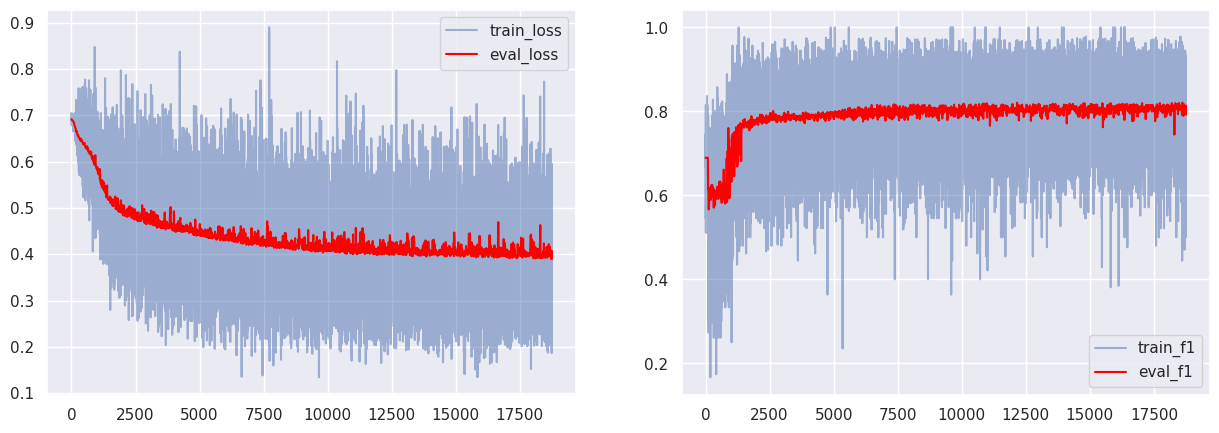

In [168]:
model = train_model(model, num_epochs=100)

In [169]:
evaluate(model, mode='test')

(0.38555712056159974, 0.8217874140666314)

Создадим улучшенную версию модели. Добавим 3 слоя с различными размерами [128, 64, 32].
Больше размер слоев -> Больше параметров модели -> больше capacity -> модель может выучить более сложные закономерности.
А также после каждого линейного слоя добавим BatchNorm и Droupout.

In [170]:
class ImprovedMLP(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size=(128, 64, 32), dropout_p=0.2, activation=nn.ReLU):
        super().__init__()
        layers = []
        layers += [
            nn.Linear(input_size, hidden_size[0]),
            nn.BatchNorm1d(hidden_size[0]),
            activation(),
            nn.Dropout(dropout_p),
        ]

        for h_in, h_out in zip(hidden_size[:-2], hidden_size[1:-1]):
            layers += [
                nn.Linear(h_in, h_out),
                nn.BatchNorm1d(h_out),
                activation(),
                nn.Dropout(dropout_p),
            ]

        layers += [
            nn.Linear(hidden_size[-2], hidden_size[-1]),
            activation(),
            nn.Dropout(dropout_p),
        ]

        layers.append(nn.Linear(hidden_size[-1], num_labels))
        self.layers = nn.Sequential(*layers)


    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred

In [171]:
model = ImprovedMLP(num_labels=1,input_size=15)
model.to(device)

ImprovedMLP(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [172]:
loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

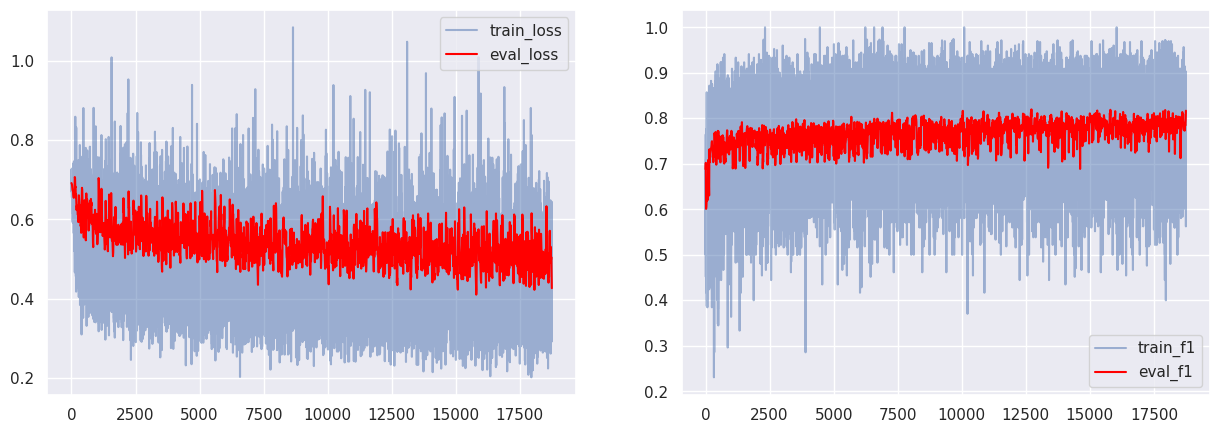

In [173]:
model = train_model(model, num_epochs=100)

In [174]:
evaluate(model, mode='test')

(0.5550337228775024, 0.7708819412039197)

Также создадим DataLoader batch_size = 128. Есть предположение, что с использованием  BatchNorm качество будет лучше на батчах большего размера

In [175]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [176]:
model = ImprovedMLP(num_labels=1, input_size=15)
model.to(device)

ImprovedMLP(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Задаем lr=1e-3, чтобы модель обучалась менее агрессивно

In [177]:
loss_function = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

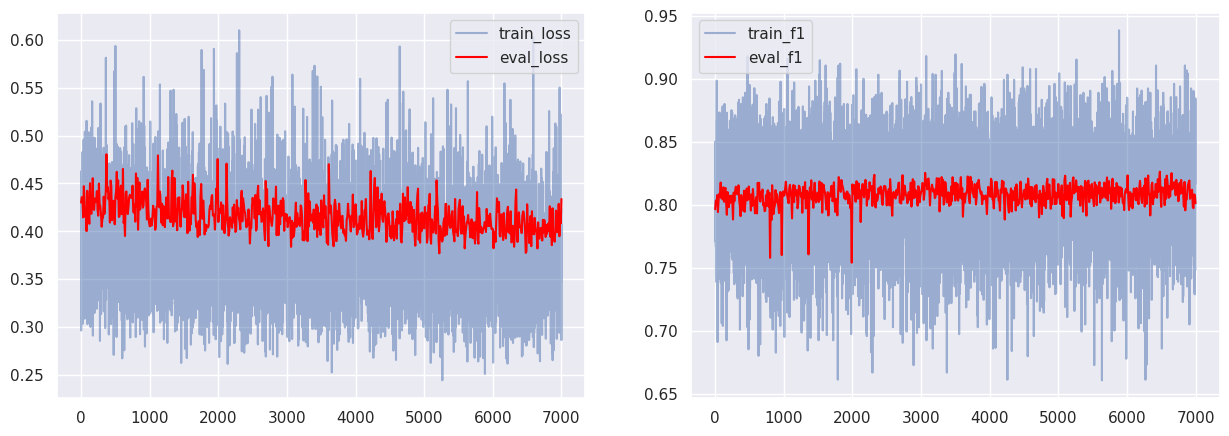

In [180]:
model = train_model(model, num_epochs=150)

In [181]:
evaluate(model, mode='test')

(0.37235092401504516, 0.8164493480441324)